In [3]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [4]:
df_org=pd.read_csv('Telco_churn_dataset.csv')

In [5]:
df_org.sample(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2064,7061-OVMIM,Female,0,Yes,Yes,30,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),19.55,608.5,No
4245,9625-RZFUK,Male,0,Yes,Yes,63,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.70,1275.85,No
2689,8628-MFKAX,Female,1,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),116.75,8277.05,No
5553,6629-CZTTH,Male,0,No,No,1,Yes,No,DSL,No,...,No,No,No,Yes,Month-to-month,Yes,Mailed check,55.70,55.7,Yes


In [6]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

binary_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

multi_cols = [
    'gender',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

In [7]:
X = df_org.drop('Churn', axis=1)
Y = df_org['Churn']

In [8]:
Y = Y.map({
    'Yes':1,
    'No':0
})
Y = Y.astype(int)

In [9]:
Y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int32

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer)
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV

# Evaluation Metrics
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)

# Ignore Warnings
import warnings

warnings.filterwarnings('ignore')


num_columns = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

multi_columns = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

binary_columns = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
]


def basic_cleaning(df1):

    df1 = df1.copy()

    # Remove customerID
    df1 = df1.drop('customerID', axis=1)

    # Convert TotalCharges
    df1['TotalCharges'] = pd.to_numeric(df1['TotalCharges'],errors='coerce')

    # Fill missing values
    df1['TotalCharges'] = df1['TotalCharges'].fillna(df1['TotalCharges'].median())

    # Binary mapping
    binary_map = {
        'Yes':1,
        'No':0,
        'Female':0,
        'Male':1
    }

    for col in binary_columns:
        df1[col] = df1[col].map(binary_map)

    return df1

In [12]:
preprocessor = ColumnTransformer([('num', StandardScaler(), num_columns ),
                                  ('cat', OneHotEncoder(drop='first'),multi_columns)
                                  ],remainder='passthrough')

In [17]:
naive_pipe = Pipeline([
    ('cleaning',FunctionTransformer(basic_cleaning)),
    ('preprocessing',preprocessor),
    ('model', GaussianNB())])

BASELINE NAIVE BAYES MODEL

In [18]:
naive_pipe.fit(X_train, y_train)

,steps,"[('cleaning', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function bas...0025858156AC0>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [19]:
y_pred = naive_pipe.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score

print("Accuracy:",accuracy_score(y_test, y_pred)*100)

Accuracy: 66.57203690560681


In [22]:

print(classification_report( y_test,y_pred ))
     

              precision    recall  f1-score   support

           0       0.94      0.58      0.72      1036
           1       0.44      0.89      0.59       373

    accuracy                           0.67      1409
   macro avg       0.69      0.74      0.65      1409
weighted avg       0.81      0.67      0.68      1409



In [23]:
# Parameter Grid
param_grid = {

    'model__var_smoothing': [

        1e-9,

        1e-8,

        1e-7,

        1e-6,

        1e-5
    ]
}

# GridSearchCV
grid_nb = GridSearchCV(

    estimator=naive_pipe,

    param_grid=param_grid,

    cv=5,

    scoring='accuracy',

    verbose=1
)

# Train Model
grid_nb.fit(

    X_train,

    y_train
)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,Pipeline(step...aussianNB())])
,param_grid,"{'model__var_smoothing': [1e-09, 1e-08, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,func,<function bas...0025858156AC0>


In [24]:

print(
    grid_nb.best_params_
)

print("\nBest Accuracy : ")

print(
    grid_nb.best_score_
)
     

{'model__var_smoothing': 1e-09}

Best Accuracy : 
0.6561980201764851


In [25]:

nb_results = pd.DataFrame(

    grid_nb.cv_results_
)

nb_results[[

    'param_model__var_smoothing',

    'mean_test_score'
]]
     

,param_model__var_smoothing,mean_test_score
0,1.000000e-09,0.656198
1,1.000000e-08,0.656198
2,1.000000e-07,0.656198
3,1.000000e-06,0.656198
4,1.000000e-05,0.656198


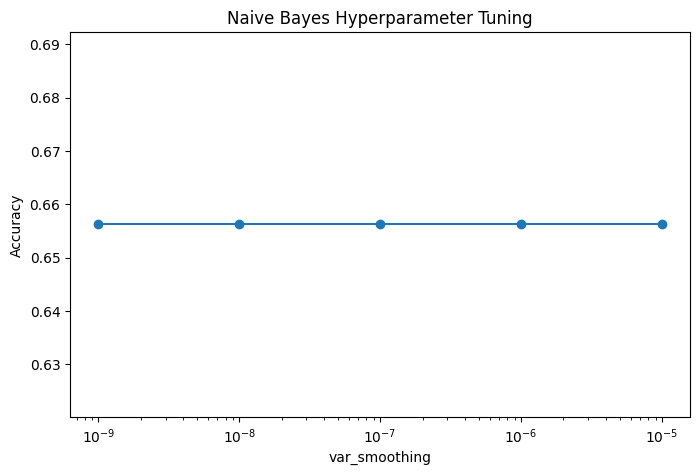

In [26]:
# Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(

    nb_results[
        'param_model__var_smoothing'
    ],

    nb_results[
        'mean_test_score'
    ],

    marker='o'
)

plt.xscale('log')

plt.title(
    "Naive Bayes Hyperparameter Tuning"
)

plt.xlabel(
    "var_smoothing"
)

plt.ylabel(
    "Accuracy"
)

plt.show()

In [ ]:
#Accuracy is same because the model already converged early.

GridSearchCV was used to perform hyperparameter tuning on the Gaussian Naive Bayes model.

GridSearchCV automatically tests different hyperparameter values using cross-validation and selects the best-performing configuration.

In Gaussian Naive Bayes, the var_smoothing parameter is used to improve numerical stability by adding a small value to the variance.

Different var_smoothing values were tested to observe their effect on model accuracy.

However, the baseline and tuned Naive Bayes models both achieved the same accuracy of 65.6198%.

This indicates that the dataset is already well-behaved and stable, and changing the var_smoothing parameter did not significantly influence the prediction performance.

Therefore, hyperparameter tuning produced minimal impact on the Gaussian Naive Bayes model for this dataset.